# LSTM Notebook

This notebook provides an example of working with the LSTM model. It
shows the process of loading per-game data for premier league forwards for
the current season, splitting into train/test sets, creating datasets and
dataloaders from them, training a `FootballLSTM` instance, and evaluating
it.

In [1]:
import sys
import os
from understatapi import UnderstatClient
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from matplotlib import pyplot as plt

# Also import local helpers
target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)
    
from preprocess import get_position_players_stats_df, CustomFootballDataset
from football_lstm import FootballLSTM
from utils import hyperparam_tuning

In [2]:
# have GPU available to speed up
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cuda


In [3]:
# Create understat connection
understat = UnderstatClient()

In [4]:
# Choose what stats to forecast, and how many past games to use to predict
# the current one
stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
games_per_block = 10

In [5]:
# Get forward stats for all seasons in top 5 leagues
leagues = ["EPL", "La_Liga", "Bundesliga", "Serie_A", "Ligue_1"]
seasons = [2021,2022,2023,2024,2025]

# save dataset to csv to avoid pulls

f_stats = get_position_players_stats_df(understat, ['F'], games_per_block, stats, leagues=leagues, seasons=seasons)
f_stats.head()

goals_per_90  xG_per_90  assists_per_90  xA_per_90  \
player_id date                                                             
844       2016-04-16      0.000000   0.346775        0.000000   0.034238   
          2016-12-15      0.311419   0.761127        0.000000   0.020791   
          2017-04-05      0.526316   0.481310        0.175439   0.049874   
          2017-09-09      0.364372   0.208623        0.182186   0.083220   
          2017-12-02      0.105018   0.190014        0.000000   0.034426   

                      key_passes_per_90  xGChain_per_90  xGBuildup_per_90  
player_id date                                                             
844       2016-04-16           1.054688        0.549815          0.201408  
          2016-12-15           0.622837        0.726827          0.000000  
          2017-04-05           0.526316        0.502992          0.081532  
          2017-09-09           1.093117        0.262322          0.045774  
          2017-12-02           0.420070        0.253562          0.037266

In [6]:
# Train/test split
train_len = int(len(f_stats) * 0.8)
train_df = f_stats.iloc[:train_len]
test_df = f_stats.iloc[train_len:]

In [7]:
train_df.head()

goals_per_90  xG_per_90  assists_per_90  xA_per_90  \
player_id date                                                             
844       2016-04-16      0.000000   0.346775        0.000000   0.034238   
          2016-12-15      0.311419   0.761127        0.000000   0.020791   
          2017-04-05      0.526316   0.481310        0.175439   0.049874   
          2017-09-09      0.364372   0.208623        0.182186   0.083220   
          2017-12-02      0.105018   0.190014        0.000000   0.034426   

                      key_passes_per_90  xGChain_per_90  xGBuildup_per_90  
player_id date                                                             
844       2016-04-16           1.054688        0.549815          0.201408  
          2016-12-15           0.622837        0.726827          0.000000  
          2017-04-05           0.526316        0.502992          0.081532  
          2017-09-09           1.093117        0.262322          0.045774  
          2017-12-02           0.420070        0.253562          0.037266

In [8]:
# Create datasets
blocks_per_input = 5

train_dataset = CustomFootballDataset(train_df, blocks_per_input, multiple_players=True)
test_dataset = CustomFootballDataset(test_df, blocks_per_input, multiple_players=True)

In [9]:
len(train_dataset)

8751

In [10]:
# Create dataloaders

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

FileNotFoundError: [Errno 2] No such file or directory: 'tuning_graphs/lr0.001_ep50_ly1_hs32_do0.png'

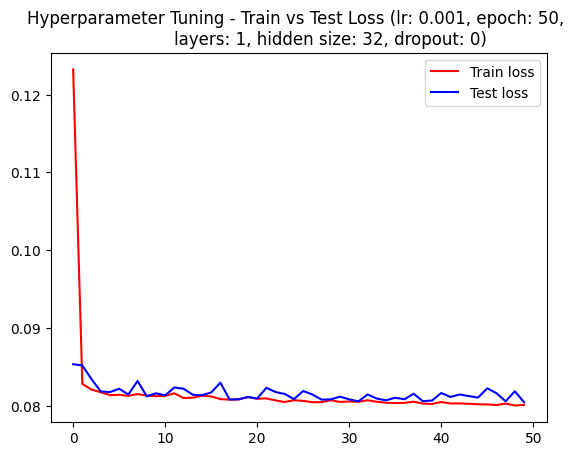

In [ ]:
# Tuning params
params = {
    "learning_rates": [0.01, 0.001, 0.0001],
    "epochs": [10, 20, 30],
    "h_sizes": [16, 32, 64, 128],
    "layers": [1, 2, 3, 4],
    "dropouts": [0.2, 0.3, 0.5]
}

opt_hyper_params = hyperparam_tuning(params, stats_df=f_stats, train_dataloader=train_dataloader, 
                                             test_dataloader=test_dataloader)

print(f"""
      Best Hyperparameter setup \n
      - learning rate: {opt_hyper_params['learning_rate']} 
      - number of epochs: {opt_hyper_params['epoch']}.
      - number of layers: {opt_hyper_params['layers']}.
      - hidden size: {opt_hyper_params['hidden_size']}.
      - dropout: {opt_hyper_params['dropout']}.
      """)

In [ ]:
# Tuned setup to MSE Loss and Adam
loss_fn = nn.MSELoss()
model = FootballLSTM(n_features=len(f_stats.columns), hidden_size=opt_hyper_params['hidden_size'], 
                     num_layers=opt_hyper_params['hidden_size'], dropout=opt_hyper_params['dropout']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=opt_hyper_params['learning_rate'])
num_epochs = opt_hyper_params['epoch']

# Train model
train_losses, test_losses = model.train_model(
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs
)

In [ ]:
# Evaluate test performance

rmse, mae = model.eval_model(test_dataloader)
print(f"Test RMSE: {rmse}")
print(f"Test MAE: {mae}")

In [ ]:
# See how model does on forecasting a specific player--Erling Haaland

haaland_df = f_stats.loc["8260"]

model.eval_model_on_player(haaland_df)